In [29]:
### Data Dictionary (Italian Customs & Aviation Terminology)

##1. Temporal Features (Time & Date)**
# `DATA_PARTENZA`: Departure Date (Full timestamp).
# `ANNO_PARTENZA` / `MESE_PARTENZA` / `GIORNO_PARTENZA`: Year / Month / Day of departure.

##2. Geographical & Airport Features**
# `AREOPORTO_PARTENZA` / `AREOPORTO_ARRIVO`: Departure / Arrival Airport Code (e.g., FCO, JFK).
# `DESCR_AEREOPORTO_...`: Full Airport Name (e.g., Fiumicino, John F Kennedy).
# `CITTA_PARTENZA` / `CITTA_ARR`: Departure / Arrival City.
# `PAESE_PART` / `PAESE_ARR`: Departure / Arrival Country.
# `CODICE_PAESE_...`: Country Code (e.g., ITA, USA).
# `ZONA` / `3zona`: Geographical routing zone.

##3. Flight & Airline Info**
# `COMPAGNIA_AEREA` / `compagnia%aerea`: Airline Name.
# `NUMERO_VOLO` / `num volo`: Flight Number.
# `FLAG_TRANSITO`: Indicates if it's a transit flight (Connecting flight).

##4. Passenger Demographics (Travelers Dataset)**
# `NAZIONALITA` / `3nazionalita`: Passenger Nationality.
# `GENERE`: Gender.
# `FASCIA_ETA` / `FASCIA ETA`: Age Group (e.g., 18-30).
# `TIPO_DOCUMENTO` / `Tipo Documento`: Document used (Passport, ID Card).

##5. Quantitative Metrics (The Numbers)**
# `TOT` / `tot voli`: Number of alarms for a specific occurenzi
# `ENTRATI`: Total number of passengers who *entered* the system/country.
# `INVESTIGATI`: Number of passengers *investigated* (Level 1 check).
# `ALLARMATI`: Number of passengers flagged with an *alarm* (Level 2 check/Anomaly).

##6. Customs & Risk Assessment (The Labels)**
# `OCCORRENZE`: Type of event/occurrence recorded.
# `MOTIVO_ALLARME`: Reason for the alarm/flag. (who has raised the alarm)
# `ESITO_CONTROLLO`: Outcome of the inspection (e.g., Cleared, Rejected, Arrested).
# `codice_rischio` / `flag_rischio`: Risk code/flag (mostly missing data, >98% NaNs).
# `note_operatore`: Customs operator's manual notes (mostly missing data, >98% NaNs).

In [30]:
### Step 1: Initial Data Inspection
#In this first step, we load the raw datasets and perform a global structural inspection. 
#For each dataset, we will extract:
#1. **Shape:** The total number of rows and columns.
#2. **Data Overview:** A summary table containing Data Types, Missing Values, and Cardinality (Unique Values) to understand the nature of each feature.
#3. **Data Sample:** The first 5 rows to visualize the actual content.

In [25]:
import pandas as pd
from IPython.display import display

# Load datasets
df_alarms = pd.read_csv("ALLARMI.csv")
df_travelers = pd.read_csv("TIPOLOGIA_VIAGGIATORE.csv")

# Create a clean, reusable function for dataset inspection
def inspect_dataset(df, dataset_name):
    print(f"\n{'='*60}")
    print(f"--- {dataset_name} DATASET ---")
    print(f"{'='*60}")
    
    # 1. Shape
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
    
    # 2. Global Overview (Types, Missing, Cardinality)
    # We build a custom summary dataframe for a much cleaner output than .info()
    overview = pd.DataFrame({
        'Data Type': df.dtypes,
        'Missing Values': df.isnull().sum(),
        'Missing_Percent': (df.isnull().sum() / len(df) * 100).round(2),
        'Unique Values (Cardinality)': df.nunique()
    })
    
    print("Data Overview:")
    display(overview)
    
    # 3. First few rows
    print("\nFirst 5 rows:")
    display(df.head())

# Execute the inspection for both datasets
inspect_dataset(df_alarms, "ALARMS (ALLARMI)")
inspect_dataset(df_travelers, "TRAVELERS (TIPOLOGIA_VIAGGIATORE)")


--- ALARMS (ALLARMI) DATASET ---
Shape: 5080 rows, 24 columns

Data Overview:


,Data Type,Missing Values,Missing_Percent,Unique Values (Cardinality)
OCCORRENZE,object,0,0.00,30
AREOPORTO_ARRIVO,object,0,0.00,77
AREOPORTO_PARTENZA,object,0,0.00,208
ANNO_PARTENZA,object,0,0.00,5
MESE_PARTENZA,object,0,0.00,14
DATA_PARTENZA,object,0,0.00,3810
DESCR_AEREOPORTO_ARR,object,0,0.00,31
DESCR_AEREOPORTO_PART,object,109,2.15,136
CITTA_ARR,object,0,0.00,29
CITTA_PARTENZA,object,101,1.99,110



First 5 rows:


,OCCORRENZE,AREOPORTO_ARRIVO,AREOPORTO_PARTENZA,ANNO_PARTENZA,MESE_PARTENZA,DATA_PARTENZA,DESCR_AEREOPORTO_ARR,DESCR_AEREOPORTO_PART,CITTA_ARR,CITTA_PARTENZA,...,ZONA,TOT,MOTIVO_ALLARME,note_operatore,flag_rischio,Paese Partenza,CODICE PAESE ARR,3zona,paese%arr,tot voli
0,Voli con Allarmi,FCO,IST,2024,01,2024-01-30 09:15:00,Fiumicino,Havalimani,Roma,Istanbul,...,5,1,Manuale,NaN,NaN,Turchia,ITA,5,Italia,1
1,Viaggiatori con Allarmi,CIA,STN,2024,02,2024-02-03 13:15:00,Ciampino,Stansted,Roma,Londra,...,5,5,Manuale,NaN,NaN,Regno Unito,ITA,5,Italia,5
2,Viaggiatori entrati nel Sistema,FCO,LHR,2024,01,2024-01-15 08:45:00,Fiumicino,London Heathrow,Roma,Londra,...,5,110,TSC,NaN,NaN,Regno Unito,ITA,5,Italia,110
3,Voli con Allarmi,MXP,LHR,2024,02,2024-02-02 08:40:00,Malpensa,London Heathrow,Milano,Londra,...,2,1,SDI,NaN,NaN,Regno Unito,ITA,2,Italia,1
4,Viaggiatori con Allarmi,PSA,BRS,2024,02,2024-02-16 12:50:00,Galileo Galilei,Bristol,Pisa,Bristol,...,8,2,INTERPOL,NaN,NaN,Regno Unito,ITA,8,Italia,2



--- TRAVELERS (TIPOLOGIA_VIAGGIATORE) DATASET ---
Shape: 5095 rows, 33 columns

Data Overview:


,Data Type,Missing Values,Missing_Percent,Unique Values (Cardinality)
NAZIONALITA,object,116,2.28,19
AREOPORTO_ARRIVO,object,0,0.00,79
AREOPORTO_PARTENZA,object,0,0.00,242
ANNO_PARTENZA,object,0,0.00,4
MESE_PARTENZA,object,0,0.00,5
GIORNO_PARTENZA,int64,0,0.00,31
DATA_PARTENZA,object,0,0.00,3977
DESCR_AEREOPORTO_ARR,object,0,0.00,29
DESCR_AEREOPORTO_PART,object,0,0.00,176
CITTA_ARR,object,0,0.00,27



First 5 rows:


,NAZIONALITA,AREOPORTO_ARRIVO,AREOPORTO_PARTENZA,ANNO_PARTENZA,MESE_PARTENZA,GIORNO_PARTENZA,DATA_PARTENZA,DESCR_AEREOPORTO_ARR,DESCR_AEREOPORTO_PART,CITTA_ARR,...,COMPAGNIA_AEREA,NUMERO_VOLO,ESITO_CONTROLLO,note_operatore,codice_rischio,Tipo Documento,FASCIA ETA,3nazionalita,compagnia%aerea,num volo
0,ALB,NAP,DUR,2024,02,13,2024-02-13 07:30:00,Napoli Capodichino,King Shaka International,Napoli,...,Fly Dubai,FZ1681,RESPINTO,NaN,NaN,Passaporto,N.D.,ALB,Fly Dubai,FZ1681
1,NaN,FCO,JFK,2024,01,22,2024-01-22 16:35:00,Fiumicino,John F Kennedy International,Roma,...,ITA Airways,AZ0609,NaN,NaN,NaN,Carta d'identità,18-30,ALB,ITA Airways,AZ0609
2,ALB,TSF,TIA,2024,02,4,2024-02-04 20:10:00,Treviso-Sant'Angelo,Rinas Mother Teresa,Treviso,...,Ryanair DAC,FR8400,SEGNALATO,NaN,NaN,N.D.,31-45,ALB,Ryanair DAC,FR8400
3,AFG,FCO,IST,2024,01,25,2024-01-25 13:05:00,Fiumicino,Havalimani,Roma,...,Turkish Airlines,TK1865,NaN,NaN,NaN,N.D.,61+,AFG,Turkish Airlines,TK1865
4,ALB,BGY,MLE,2024,02,13,FEB 13 2024,Orio al Serio,Male International,Bergamo,...,Fly Dubai,FZ1571,SEGNALATO,NaN,NaN,Permesso di soggiorno,46-60,ALB,Fly Dubai,FZ1571


Missing Values - Alarms Dataset


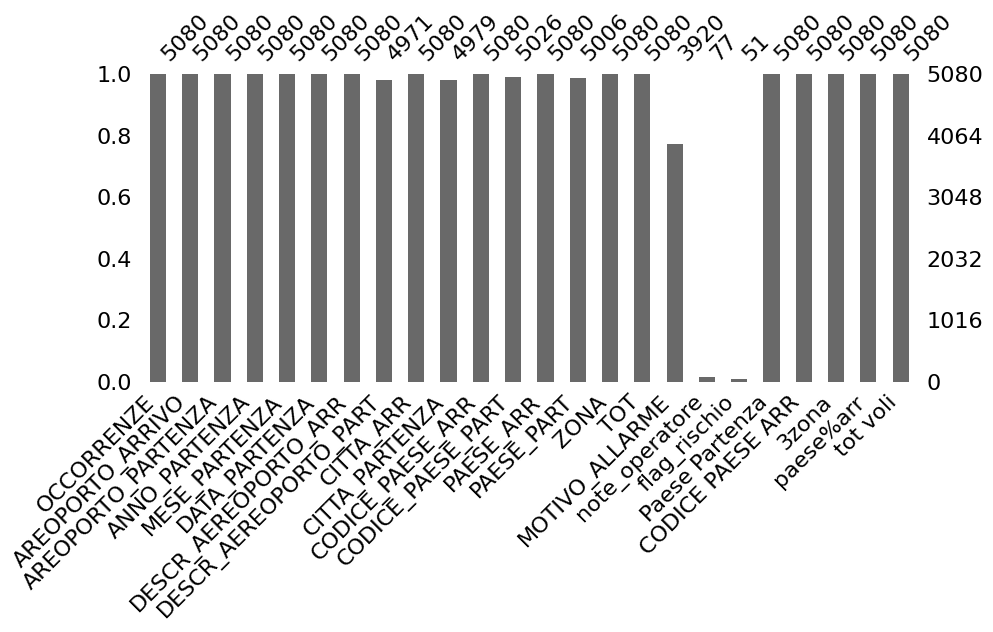

Missing Values - Travelers Dataset


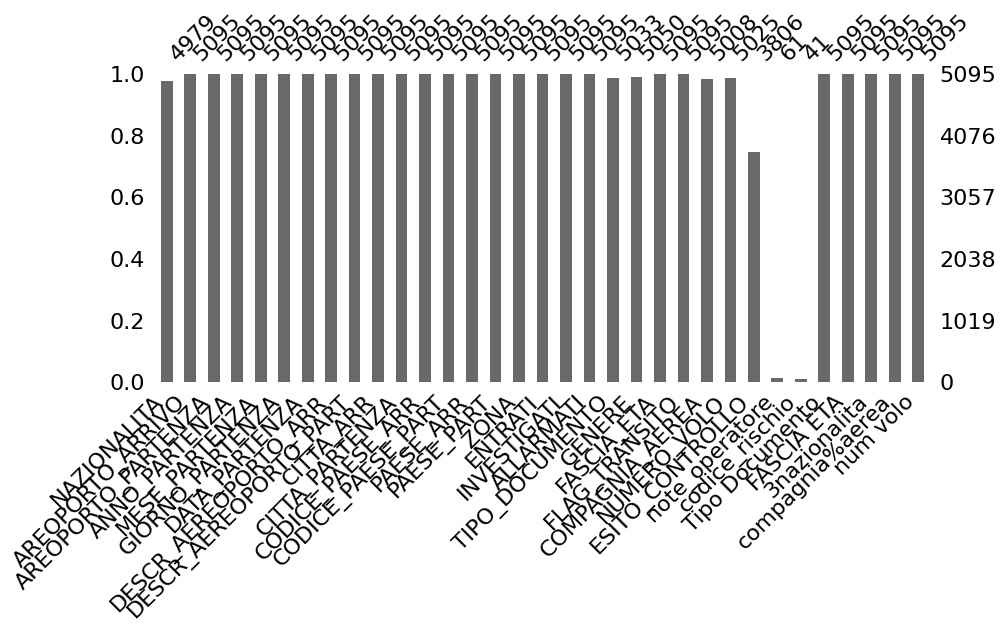

In [28]:
### Step 1.A : Missing Values Analysis
#Visualizing missing data using the `missingno` library to identify incomplete columns before data cleaning.
#!pip install missingno
# Import the required libraries
import missingno as msno
import matplotlib.pyplot as plt

# 1. Visualize missing values for the Alarms dataset
print("Missing Values - Alarms Dataset")
msno.bar(df_alarms, figsize=(10, 4))
plt.show()

# 2. Visualize missing values for the Travelers dataset
print("Missing Values - Travelers Dataset")
msno.bar(df_travelers, figsize=(10, 4))
plt.show()

In [13]:
### Step 1B: Categorical Features & Cardinality Inspection
#Before cleaning the data (Step 2), we must inspect the categorical variables (text columns). 
#We cap the visualization at 100 unique values to prevent Dates (e.g., `DATA_PARTENZA`) or dirty numerical columns (e.g., `TOT` loaded as strings) from skewing the chart. 

#This step will:
#1. **Visualize the cardinality** of standard categorical features.
#2. **Highlight extremely high cardinality columns** (requiring Datetime conversion or numeric cleaning).
#3. **List the actual unique values** alphabetically to easily spot typos and standardization issues (e.g., "GB" vs "GDB").


--- CATEGORICAL INSPECTION: ALARMS ---


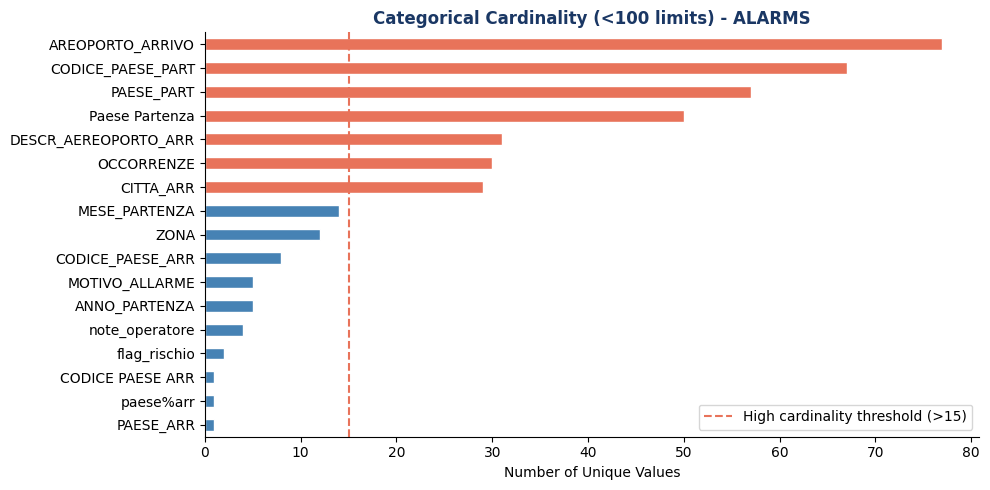


--- Unique Values Breakdown (ALARMS) ---
⚠️ HIGH CARDINALITY FEATURES (Excluded from plot):
   ➤ 'CITTA_PARTENZA': 110 unique values (Action needed in Step 2: Deep analysis and cleaning)
   ➤ 'DESCR_AEREOPORTO_PART': 136 unique values (Action needed in Step 2: Deep analysis and cleaning)
   ➤ 'AREOPORTO_PARTENZA': 208 unique values (Action needed in Step 2: Deep analysis and cleaning)
   ➤ 'tot voli': 342 unique values (Action needed in Step 2: Deep analysis and cleaning)
   ➤ 'TOT': 348 unique values (Action needed in Step 2: Deep analysis and cleaning)
   ➤ 'DATA_PARTENZA': 3810 unique values (Action needed in Step 2: Deep analysis and cleaning)
--------------------------------------------------

🔍 REVIEWING CATEGORIES (To spot typos/standardization issues):
➤ 'PAESE_ARR' (1 values):
   ['Italia']

➤ 'paese%arr' (1 values):
   ['Italia']

➤ 'CODICE PAESE ARR' (1 values):
   ['ITA']

➤ 'flag_rischio' (2 values):
   ['ALTO', 'MEDIO']

➤ 'note_operatore' (4 values):
   ['Alert manuale'

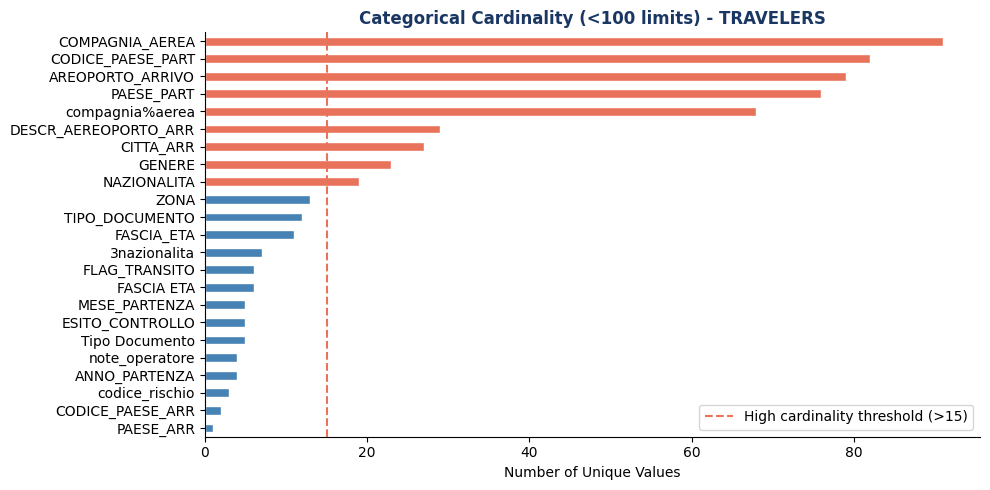


--- Unique Values Breakdown (TRAVELERS) ---
⚠️ HIGH CARDINALITY FEATURES (Excluded from plot):
   ➤ 'ALLARMATI': 146 unique values (Action needed in Step 2: Deep analysis and cleaning)
   ➤ 'CITTA_PARTENZA': 165 unique values (Action needed in Step 2: Deep analysis and cleaning)
   ➤ 'DESCR_AEREOPORTO_PART': 176 unique values (Action needed in Step 2: Deep analysis and cleaning)
   ➤ 'AREOPORTO_PARTENZA': 242 unique values (Action needed in Step 2: Deep analysis and cleaning)
   ➤ 'ENTRATI': 251 unique values (Action needed in Step 2: Deep analysis and cleaning)
   ➤ 'INVESTIGATI': 251 unique values (Action needed in Step 2: Deep analysis and cleaning)
   ➤ 'NUMERO_VOLO': 701 unique values (Action needed in Step 2: Deep analysis and cleaning)
   ➤ 'num volo': 706 unique values (Action needed in Step 2: Deep analysis and cleaning)
   ➤ 'DATA_PARTENZA': 3977 unique values (Action needed in Step 2: Deep analysis and cleaning)
--------------------------------------------------

🔍 REVIEWIN

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

def inspect_categorical_clean(df, dataset_name):
    print(f"\n{'='*60}")
    print(f"--- CATEGORICAL INSPECTION: {dataset_name} ---")
    print(f"{'='*60}")
    
    # Select only categorical (text) columns
    cat_cols = df.select_dtypes(include=['object']).columns
    if len(cat_cols) == 0:
        return
        
    # Calculate cardinality
    card = df[cat_cols].nunique().sort_values(ascending=True)
    
    # --- 1. FILTER FOR VISUALIZATION ---
    # Keep only columns with <= 100 unique values for the chart
    card_to_plot = card[card <= 100]
    high_card_cols = card[card > 100]
    
    if not card_to_plot.empty:
        plt.figure(figsize=(10, 5))
        colors = ['#E8735A' if v > 15 else '#4682B4' for v in card_to_plot]
        card_to_plot.plot(kind='barh', color=colors, edgecolor='white')
        plt.axvline(15, color='#E8735A', ls='--', lw=1.5, label='High cardinality threshold (>15)')
        plt.title(f'Categorical Cardinality (<100 limits) - {dataset_name}', fontweight='bold', color='#1A3764')
        plt.xlabel('Number of Unique Values')
        plt.legend()
        sns.despine()
        plt.tight_layout()
        plt.show()
    
    # --- 2. TEXT BREAKDOWN ---
    print(f"\n--- Unique Values Breakdown ({dataset_name}) ---")
    
    # Display the problematic columns we excluded from the chart
    if not high_card_cols.empty:
        print("⚠️ HIGH CARDINALITY FEATURES (Excluded from plot):")
        for col, val in high_card_cols.items():
            print(f"   ➤ '{col}': {val} unique values (Action needed in Step 2: Deep analysis and cleaning)")
        print("-" * 50)
        
    print("\n🔍 REVIEWING CATEGORIES (To spot typos/standardization issues):")
    for col in card_to_plot.index:
        # Sort values alphabetically
        unique_vals = sorted(df[col].dropna().astype(str).unique())
        print(f"➤ '{col}' ({len(unique_vals)} values):")
        print(f"   {unique_vals}\n")

# Execute the clean inspection
inspect_categorical_clean(df_alarms, "ALARMS")
inspect_categorical_clean(df_travelers, "TRAVELERS")

In [ ]:
### Step 2: Data Cleaning & Preprocessing
#Initial inspection revealed that pandas loaded almost all columns as strings (`object`). 
#To perform summary statistics pragmatically, we cast temporal features to `datetime` and quantitative features to `numeric`. 
#Bad data (e.g., text in a number column) is coerced to NaN.
#=> NEED TO BE CHECK By Giulio

In [24]:
# --- 1. Dates and Temporal Categories ---
# We convert the full date to datetime, but leave ANNO (Year) and MESE (Month) as objects (categorical)
df_alarms['DATA_PARTENZA'] = pd.to_datetime(df_alarms['DATA_PARTENZA'], errors='coerce')
df_travelers['DATA_PARTENZA'] = pd.to_datetime(df_travelers['DATA_PARTENZA'], errors='coerce')

# --- 2. Forcing Quantitative Variables to Numeric ---
# 'coerce' will turn any hidden text (like "N/A" or " ") into a clean NaN (Missing Value)
quant_alarms = ['TOT', '3zona', 'tot voli', 'ZONA']
df_alarms[quant_alarms] = df_alarms[quant_alarms].apply(pd.to_numeric, errors='coerce')

quant_travelers = ['ENTRATI', 'INVESTIGATI', 'ALLARMATI']
df_travelers[quant_travelers] = df_travelers[quant_travelers].apply(pd.to_numeric, errors='coerce')

# --- 3. Verification ---
print("Conversion Complete.")
print(f"Alarms dataset now has {len(df_alarms.select_dtypes(include=['float64', 'int64']).columns)} numerical columns.")
print(f"Travelers dataset now has {len(df_travelers.select_dtypes(include=['float64', 'int64']).columns)} numerical columns.")

Conversion Complete.
Alarms dataset now has 4 numerical columns.
Travelers dataset now has 4 numerical columns.


In [15]:
### Step 3: Summary Statistics (Center, Spread, Shape) & First Insights & Trends
#With proper data types established, we compute the summary statistics for our quantitative features. This analysis focuses on the three pillars:
#1. **Center**: Mean and Median (50th percentile).
#2. **Spread**: Standard Deviation (std) and Min/Max ranges to detect impossible values.
#3. **Shape**: Skewness to identify highly asymmetrical distributions (where Skewness > 1 indicates a strong right tail, typical in anomaly/fraud detection).
# NEED to be finish and make it clearer

In [18]:
# --- Step 3: Summary Statistics ---
import pandas as pd

# Define the true quantitative variables based on our dictionary
quant_travelers = ['ENTRATI', 'INVESTIGATI', 'ALLARMATI']
quant_alarms = ['TOT', 'tot voli']

print("="*50)
print("--- 3A. SUMMARY STATISTICS: TRAVELERS ---")
print("="*50)
# Display Center and Spread (describe calculates count, mean, std, min, quartiles, max)
display(df_travelers[quant_travelers].describe().T.round(2))

print("\n--- SHAPE (SKEWNESS): TRAVELERS ---")
# Calculate Skewness and flag highly skewed features
skew_trav = df_travelers[quant_travelers].skew().round(2)
skew_df_trav = pd.DataFrame({'Skewness': skew_trav})
skew_df_trav['High_Skew_Flag'] = skew_df_trav['Skewness'].abs() > 1
display(skew_df_trav)

print("\n" + "="*50)
print("--- 3B. SUMMARY STATISTICS: ALARMS ---")
print("="*50)
display(df_alarms[quant_alarms].describe().T.round(2))

print("\n--- SHAPE (SKEWNESS): ALARMS ---")
skew_al = df_alarms[quant_alarms].skew().round(2)
skew_df_al = pd.DataFrame({'Skewness': skew_al})
skew_df_al['High_Skew_Flag'] = skew_df_al['Skewness'].abs() > 1
display(skew_df_al)

--- 3A. SUMMARY STATISTICS: TRAVELERS ---


,count,mean,std,min,25%,50%,75%,max
ENTRATI,4892.0,42.24,251.42,-500.0,1.0,3.0,76.0,10000.0
INVESTIGATI,4892.0,41.54,229.92,-3.0,1.0,2.0,75.0,9999.0
ALLARMATI,4892.0,7.41,73.05,-500.0,0.0,1.0,10.0,5000.0



--- SHAPE (SKEWNESS): TRAVELERS ---


,Skewness,High_Skew_Flag
ENTRATI,38.12,True
INVESTIGATI,37.34,True
ALLARMATI,65.27,True



--- 3B. SUMMARY STATISTICS: ALARMS ---


,count,mean,std,min,25%,50%,75%,max
TOT,4924.0,85.10,2025.66,-500.0,1.0,2.0,28.0,99999.0
tot voli,4924.0,40.81,75.31,0.0,1.0,2.0,28.0,544.0



--- SHAPE (SKEWNESS): ALARMS ---


,Skewness,High_Skew_Flag
TOT,48.82,True
tot voli,2.13,True
